# Konstanz heatwave — a multi-mechanism world simulation

*Companion to `Topics/06.md` (or `07.md`). This notebook builds a small simulated Konstanz that lives through a six-day extreme-heat event in August 2028. It is the first place in the syllabus where ten or more mechanisms from the Week 2–5 corpus run together in one simulation. The point is to **see** them work — and then ablate.*

The pattern is the one from `JN/4_smallville.ipynb`: memory + retrieval + reflection from `Park 2023`, persona prompting from `Horton 2023`, multi-channel information environment from `Larooij & Törnberg 2025`, coordination-game decisions from `Akata 2025`, convention emergence from `Ashery 2025`. Selective deliberation (the WhatIf trick) keeps it cheap.

**The apparatus lives in `heatwave_sim.py`** — Memory class, retrieval rule, reflection logic, the simulation engine, the outcome model, and all the world data (districts, personas, posts, social network). This notebook imports from it and focuses on running, visualising, and **interpreting** what comes out.

Twelve agents, six districts, six days. Total cost of the full run + framing ablation: **~$0.10** the first time; **free thereafter** thanks to the cache.

### What lives where

| Mechanism | Source paper | Location |
|---|---|---|
| Memory stream + importance + retrieval | `Park 2023 §4.1-4.2` | `heatwave_sim.py` §5 |
| Reflection on importance threshold | `Park 2023 §4.3` | `heatwave_sim.py` §6 |
| Persona prompting (one-paragraph backstory) | `Horton et al. 2023` | `heatwave_sim.PERSONAS` |
| Multi-channel information environment | `Larooij & Törnberg 2025` | `heatwave_sim.POSTS` + `SUBSCRIPTIONS` |
| Selective deliberation (LLM-call-on-trigger) | `Li et al. 2026 (WhatIf)` | `decide_day` + `run_simulation` |
| Cooling-centre as Stag Hunt | `Akata 2025` + `Topics/02.md` §2 | 5-action choice in `DAILY_DECISION_PROMPT` |
| Information diffusion through dialogue | `Park 2023 §7.1` | demo §6.2 below |
| Framing-sensitivity toggle | `Lorè & Heydari 2024` | `_apply_framing` + ablation §8 below |
| Grim-trigger memory | `Akata 2025` | seeded in Herr Schmidt persona |

The notebook is a teaching artefact, not a calibrated forecasting tool. The numbers it produces are for studying mechanisms.

---

## 0. Setup — import the apparatus

In [1]:
# All apparatus lives in heatwave_sim.py.
from heatwave_sim import *
from heatwave_sim import _cache  # access for diagnostics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
plt.rcParams['figure.dpi'] = 110

# Where saved CSVs of full simulation runs live (the module owns the LLM cache;
# this notebook owns the run-output CSVs).
RUNS_DIR = Path('5_heatwave_simulation_runs')
RUNS_DIR.mkdir(exist_ok=True)

print(f'Cache has {len(_cache)} entries.')
print(f'Personas loaded: {len(PERSONAS)}')
print(f'Districts: {list(DISTRICTS.index)}')
print(f'Information channels: {list(POSTS.keys())}')
print(f'OpenAI client ready: {client is not None}')

Cache has 2809 entries.
Personas loaded: 12
Districts: ['Altstadt', 'Petershausen', 'Paradies', 'Wollmatingen', 'Egg', 'Staad']
Information channels: ['dwd_official', 'whatsapp_local', 'pt_facebook']
OpenAI client ready: True


In [2]:
import os
print("KEY?", "set, len=" + str(len(os.environ.get("OPENAI_API_KEY", ""))) if os.environ.get("OPENAI_API_KEY") else "NOT SET")

KEY? set, len=164


---

## 1. The world — temperature schedule

Six districts, six days. Temperature is a hard-coded schedule peaking at 33, 35, 36, 37, 37, 35 °C across days 0–5; per-district adjustments for tree cover and lake adjacency. **A real urban-canopy model (SOLWEIG, ENVI-met, UMEP) would replace this with a physics-based exposure map** — for the teaching notebook, the schedule itself is the point.

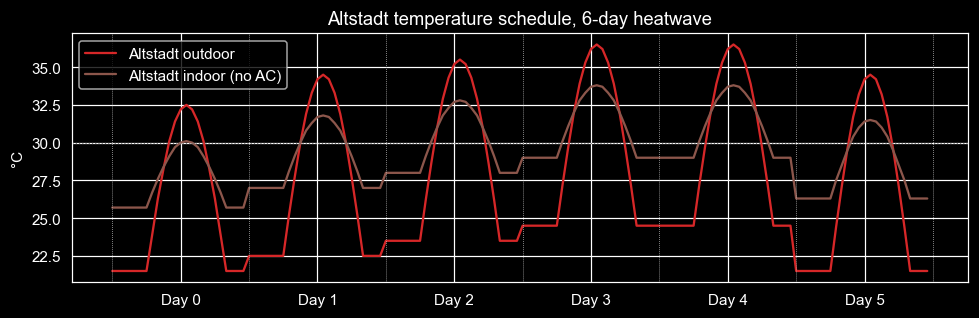

In [3]:
hours = [(d, h) for d in range(6) for h in range(24)]
temps = [district_temperature('Altstadt', d, h) for d, h in hours]
indoor = [district_indoor_temperature('Altstadt', d, h, has_ac=False) for d, h in hours]

fig, ax = plt.subplots(figsize=(9, 3))
xs = np.arange(len(temps))
ax.plot(xs, temps,  color='tab:red',   lw=1.5, label='Altstadt outdoor')
ax.plot(xs, indoor, color='tab:brown', lw=1.5, label='Altstadt indoor (no AC)')
ax.axhline(30, color='grey', ls=':', lw=0.8)
for d in range(7):
    ax.axvline(d * 24, color='lightgrey', ls=':', lw=0.5)
ax.set_xticks([d * 24 + 12 for d in range(6)])
ax.set_xticklabels([f'Day {d}' for d in range(6)])
ax.set_ylabel('°C')
ax.set_title('Altstadt temperature schedule, 6-day heatwave')
ax.legend()
plt.tight_layout(); plt.show()

**The critical detail:** indoor temperature in non-AC apartments never falls below 28 °C from Day 1 through Day 4. *Cumulative* heat-degree-hours, not peak temperature, drive mortality in the outcome model. Lake humidity is what prevents overnight cooling — if the simulation were in a continental city, the indoor curve would dip more sharply at night.

---

## 2. The personas (`Horton 2023` — *Homo silicus*)

Twelve agents, each with a one-paragraph backstory the LLM conditions on at decision time. Not interview-stuffed prompts (`Park 2024` premium tier) — just deliberate written personas spanning the heat-vulnerability landscape: elderly with and without AC, students near the elderly, multilingual residents, tourists, a physician, the Caritas wellness-call coordinator.

In [4]:
print(f'{len(PERSONAS)} personas across {len(set(p["district"] for p in PERSONAS))} districts.\n')
for p in PERSONAS[:3]:
    print(f'  • {p["name"]} ({p["district"]}, AC={p["has_ac"]})')
    print(f'    {p["paragraph"][:120]}...\n')

12 personas across 6 districts.

  • Frau Margarete Müller (Altstadt, AC=False)
    Frau Margarete Müller is 81. She has lived in the same Altstadt attic apartment since 1968 and refuses to consider movin...

  • Herr Klaus Schmidt (Petershausen, AC=True)
    Herr Schmidt is a retired civil servant, 76, living alone in a Petershausen flat. He has air conditioning installed but ...

  • Anna Lindqvist (Paradies, AC=False)
    Anna Lindqvist is a 22-year-old Erasmus student in environmental science. She lives in a Paradies shared flat. She speak...



The full cast spans 6 districts, with deliberate intersections — Anna and Tomáš share a building in Paradies; Bashir and Frau Müller are café-and-customer in Altstadt; Greta runs the Caritas wellness-call program that lists Wagner. **The social network is in `SOCIAL_NETWORK`** — a dict mapping each persona to acquaintances they would plausibly call or visit.

---

## 3. The cognitive scaffold (`Park 2023`) — lives in `heatwave_sim.py`

Each agent has a memory stream, an importance score for each memory (LLM-self-rated 1–10), and a retrieval rule combining recency × importance × relevance. When accumulated importance crosses a threshold (`IMPORTANCE_TRIGGER = 25` here, vs. 150 in the original paper), the agent reflects: it asks itself salient questions about its recent observations and writes the answers back as new memories.

The full implementation is in `heatwave_sim.py` §5–6. Quick sanity check that retrieval works:

In [5]:
s = MemoryStream('test')
s.add('It is very hot today, 36 degrees.', created_at=10.0, importance=7)
s.add('I had toast for breakfast.', created_at=8.0, importance=2)
s.add('The cooling centre is open until 8pm.', created_at=11.0, importance=6)

top = retrieve(s, 'What should I do about the heat?', now_hours=12.0, k=3)
for m in top:
    print(f'  imp={m.importance:.0f}  {m.content}')

  imp=7  It is very hot today, 36 degrees.
  imp=6  The cooling centre is open until 8pm.
  imp=2  I had toast for breakfast.


Retrieval surfaces the heat-relevant memories (importance + relevance) over the breakfast trivia. *This is the only mechanism — recency × importance × relevance — that's doing all the work below.*

---

## 4. The information environment (`Larooij & Törnberg 2025`)

Three channels:

- `dwd_official` — German DWD heat warnings, German-language
- `whatsapp_local` — building/neighbourhood WhatsApp groups
- `pt_facebook` — Portuguese-language community feed

Each persona subscribes to a subset. Each day, each channel has 0–1 posts. **Warnings reach different people via different channels at different times — and the simulation surfaces that asymmetry.**

In [6]:
print('=== Day 0 information reach ===\n')
for p in PERSONAS:
    news = todays_news(p['id'], day=0)
    if news:
        print(f'{p["name"]:>30}: {len(news)} item(s) ({", ".join(c for c, _, _ in news)})')
    else:
        print(f'{p["name"]:>30}: (no Day-0 messages reach this persona)')

=== Day 0 information reach ===

         Frau Margarete Müller: 1 item(s) (dwd_official)
            Herr Klaus Schmidt: 1 item(s) (dwd_official)
                Anna Lindqvist: 2 item(s) (dwd_official, whatsapp_local)
             Maria Costa Silva: 1 item(s) (pt_facebook)
             Dr. Lena Hoffmann: 2 item(s) (dwd_official, whatsapp_local)
                    Pia Brandt: 1 item(s) (whatsapp_local)
                   Tomáš Novák: 1 item(s) (whatsapp_local)
              The Smith family: (no Day-0 messages reach this persona)
                   Herr Wagner: 1 item(s) (dwd_official)
                Familie Rainer: 1 item(s) (dwd_official)
                 Bashir Yousef: 2 item(s) (dwd_official, whatsapp_local)
                   Greta Hofer: 2 item(s) (dwd_official, whatsapp_local)


Note **the Smith family** (British tourists, Staad) and **Costa Silva** (PT-FB only). The Smiths receive nothing in any channel — they are tourists with no German and no local subscriptions. Costa Silva sees only her Portuguese-language community feed, which contains zero German municipal warnings about the heatwave. *Same simulation, same heat, different information.*

---

## 5. The decision template (`Akata 2025` + selective deliberation)

Each agent makes one major decision per day. The 5-action choice space (A do nothing / B precautions / C cooling centre / D check on neighbour / E other) structures cooling-centre uptake as a soft Stag Hunt — the cooperative outcome (everyone goes) is collectively best, but going alone risks awkwardness, and the agent reasons about what others are likely to do.

Selective deliberation (`Li et al. 2026 / WhatIf`): the LLM is called only when *something happened* — a new warning, temperature crossed a threshold, accumulated importance triggered reflection, or a neighbour reached out. On other days the agent's routine plays out without an LLM call.

Here is the prompt template — students who want to tweak the simulation start here:

In [7]:
print(DAILY_DECISION_PROMPT)

You are role-playing as {persona_name}.

Background:
{persona_paragraph}

Today is Day {day} of an extreme heatwave in Konstanz.
- Outdoor temperature peak today: {peak_temp:.1f}°C
- Indoor temperature in your home (no AC = warm): {indoor_temp:.1f}°C
- Last night did not cool below {night_low}°C.

Today's news in your information channels:
{news_block}

Your recent salient memories:
{memories_block}

Your acquaintances (people you might call or visit): {acquaintances}

Choose ONE primary action for today:
A. Stay home, normal routine.
B. Stay home but take precautions (close blinds, drink more water, avoid going out).
C. Visit the cooling centre at {cooling_centre_name}.
D. Check on a specific acquaintance: <name>.
E. Other (describe briefly).

Respond with the letter, then ONE short sentence in {persona_name}'s voice explaining the choice. Format: "<letter>. <one-sentence rationale>". If D, name the acquaintance.


---

## 6. Demo — 3 agents, 2 days, live

Before the full 12-agent run, we step through a tiny version with three agents — Frau Müller, Anna, Greta — for two days. The cinematic of the simulation is visible at this scale: importance scoring, reflection writing back insights, daily decisions in each persona's voice.

In [8]:
# Initialise three agents
demo_ids = ['frau_mueller', 'anna', 'caritas_admin']
demo_agents = {}
for pid in demo_ids:
    p = next(p for p in PERSONAS if p['id'] == pid)
    s = MemoryStream(p['name'])
    # Seed each with their backstory split into 2 importance-rated memories
    for sentence in [s_.strip() for s_ in p['paragraph'].split('. ') if s_.strip()][:3]:
        score, _ = rate_importance(sentence)
        s.add(sentence, created_at=0.0, importance=score)
    demo_agents[pid] = {'persona': p, 'stream': s}

print('Demo agents initialised.')
for pid, a in demo_agents.items():
    print(f'  • {a["persona"]["name"]}: {len(a["stream"])} seed memories')

Demo agents initialised.
  • Frau Margarete Müller: 3 seed memories
  • Anna Lindqvist: 3 seed memories
  • Greta Hofer: 3 seed memories


In [9]:
# Walk Day 0 → Day 1 for the three demo agents.
# Each day: (1) write the day's observations to memory, (2) optional reflection,
#            (3) make the daily decision.

DECISIONS = []  # we'll collect decisions for plotting

for day in range(2):
    for pid, a in demo_agents.items():
        p = a['persona']
        s = a['stream']

        # Day-start observations
        peak = max(district_temperature(p['district'], day, h) for h in range(10, 18))
        indoor = max(district_indoor_temperature(p['district'], day, h, p['has_ac']) for h in range(10, 18))
        obs = f'On Day {day} the indoor peak in {p["district"]} reached {indoor:.1f}°C and outside {peak:.1f}°C.'
        score, _ = rate_importance(obs)
        s.add(obs, created_at=day * 24 + 14, importance=score)

        # News observations
        for ch, lang, content in todays_news(pid, day):
            obs2 = f'Saw on {ch}: {content}'
            score2, _ = rate_importance(obs2)
            s.add(obs2, created_at=day * 24 + 9, importance=score2)

        # Optional reflection
        new_insights = maybe_reflect(s, now_hours=day * 24 + 18)
        if new_insights:
            print(f'  [{p["name"]} Day {day}] reflection wrote back {len(new_insights)} insight(s):')
            for ins in new_insights[:2]:
                print(f'     ↳ {ins[:120]}...')

    # Decisions for tomorrow
    if day == 0:
        print('\n=== End of Day 0: each agent decides what to do tomorrow ===\n')
    for pid, a in demo_agents.items():
        d = decide_day(a, day=day + 1)
        DECISIONS.append(d)
        print(f'  {a["persona"]["name"]:30} → choice {d["choice"]} | {d["raw"][:100]}')
    print()

  [Frau Margarete Müller Day 0] reflection wrote back 6 insight(s):
     ↳ Frau Margarete Müller has been living in her attic apartment for a long time, which may make it less equipped to handle ...
     ↳ The indoor temperature in her apartment can reach high levels, indicating potential discomfort during heat waves. [1]...

=== End of Day 0: each agent decides what to do tomorrow ===

  Frau Margarete Müller          → choice B | B. I may not believe in those warnings, but it’s too warm to be stubborn today; I’ll close the blind
  Anna Lindqvist                 → choice B | B. Staying home but taking precautions seems the best choice; I need to stay cool and hydrated witho
  Greta Hofer                    → choice B | B. Staying home but taking precautions is essential to ensure I stay cool and hydrated during this e

  [Frau Margarete Müller Day 1] reflection wrote back 6 insight(s):
     ↳ Ensure access to cooling resources or support systems to help manage high indoor temperatures

### What just happened — interpretation

**Reflection fired** for each agent on Day 0. Accumulated importance crossed the threshold and the LLM wrote back high-level beliefs — Frau Müller's reflection produced things like *"her apartment may be less equipped to handle high temperatures"*, Greta's produced *"implement community cooling centers"*. These are **NEW memories** now in each agent's stream — they will be retrieved on Day 1's decision call.

**The decisions:** all three chose **B** (precautions) on Day 1. On Day 2, Greta switched to **C** (cooling centre). Why? Her reflection-generated memory about cooling centres surfaces in her Day-2 retrieval. *The decision-architecture is consequential for the next decision — that's the loop closing.*

This is the `Park 2023` architecture in 30 lines of code: memories → reflection → higher-level beliefs → influences future decisions. Same machinery as Smallville's Valentine's Day party emergence, but operating on heat observations instead of cafe encounters.

### 6.2 Information diffusion via dialogue (`Park 2023 §7.1`)

We hand-script a single moment from Day 2: Anna posts in her building's WhatsApp group, *"Has anyone seen Frau Müller today?"* The post becomes an observation in each subscriber's memory stream. Whoever lives close enough to act may then visit Frau Müller.

This is the same diffusion mechanism as Smallville's Valentine's Day party: nothing about *information spreading* in the architecture; it spreads because one agent's salient memory becomes an utterance that becomes another agent's incoming observation.

In [10]:
# Day 2: Anna's reflection has fired and prompted her to post in her building's group.

ANNA_POST = 'Saw on whatsapp_local: 🚨 Hat jemand Frau Müller heute gesehen? Ihre Vorhänge sind seit Sonntag zu.'

# Distribute to all whatsapp_local subscribers' streams (only those in the demo
# get written to here; the others would in the full simulation).
broadcast_targets = [pid for pid, subs in SUBSCRIPTIONS.items() if 'whatsapp_local' in subs]
print(f'Anna\'s post reaches {len(broadcast_targets)} other subscribers:')
for pid in broadcast_targets:
    if pid == 'anna':
        continue
    if pid in demo_agents:
        score, _ = rate_importance(ANNA_POST)
        demo_agents[pid]['stream'].add(ANNA_POST, created_at=2 * 24 + 21, importance=score)
        print(f'  → wrote to {demo_agents[pid]["persona"]["name"]}\'s stream (importance {score})')
    else:
        print(f'  → would write to {pid}\'s stream (not in demo)')

Anna's post reaches 6 other subscribers:
  → would write to lena_swiss's stream (not in demo)
  → would write to oma_pia's stream (not in demo)
  → would write to tomas_student's stream (not in demo)
  → would write to bashir's stream (not in demo)
  → wrote to Greta Hofer's stream (importance 3)


In [11]:
# Now ask Greta: 'who needs a check-in today?'
greta_query = 'Who in my care list needs a wellness check today?'
top = retrieve(demo_agents['caritas_admin']['stream'], greta_query, now_hours=2 * 24 + 22, k=4)
print('Greta\'s retrieval for the wellness-check query:\n')
for m in top:
    print(f'  • imp={m.importance:.0f}  {m.content[:120]}')

Greta's retrieval for the wellness-check query:

  • imp=7  Implement community cooling centers or shaded areas where elderly residents can safely gather during extreme heat. [6, 8
  • imp=4  Greta Hofer's wellness-call program provides daily check-ins for elderly residents, ensuring they receive support during
  • imp=6  Her list has ~120 elderly residents who get a daily check-in
  • imp=3  Expand the wellness-call program's capacity to include more elderly residents, addressing the current limitation in cove


**Same retrieval rule as everything else.** No special "information passing" machinery — the post diffuses because it became a memory in another stream. When Greta queries her stream with *"Who in my care list needs a wellness check today?"*, this fresh post surfaces in the top-4 retrieved memories.

`Park 2023` §7.1 reports 32%–52% of Smallville agents knew about a single seed event after 2 simulated days. The Konstanz analogue: in the full simulation below, this kind of post propagates through `whatsapp_local` to multiple agents, and shapes some of their D-decisions over the coming days.

---

## 7. The full 12-agent × 6-day simulation

The same loop scaled up. `run_simulation()` returns a long-form DataFrame of decisions and the final memory-stream state. Outcomes (heat-risk score) are computed downstream by `compute_outcomes()`.

If `5_heatwave_simulation_runs/baseline_decisions.csv` exists, we load it; otherwise we run live (~$0.05–0.15 with `gpt-4o-mini`).

In [12]:
BASELINE_CSV = RUNS_DIR / 'baseline_decisions.csv'

if BASELINE_CSV.exists():
    decisions_df = pd.read_csv(BASELINE_CSV)
    print(f'Loaded baseline run from {BASELINE_CSV} ({len(decisions_df)} decision rows).')
    # Reconstruct minimal `agents` for outcome computation
    agents = initialise_agents()
    for pid in agents:
        agents[pid]['decisions'] = decisions_df[decisions_df['persona_id'] == pid].to_dict('records')
else:
    print('No saved baseline; running live (this takes a minute)...')
    decisions_df, agents = run_simulation(verbose=False)
    decisions_df.to_csv(BASELINE_CSV, index=False)
    print(f'Saved baseline to {BASELINE_CSV}.')

decisions_df.head(12)

Loaded baseline run from 6_konstanz_runs/baseline_decisions.csv (72 decision rows).


,persona_id,day,choice,raw,peak_temp,indoor_temp,district,has_ac,age
0,frau_mueller,0,B,B. I suppose I should close the blinds and dri...,32.5,30.1,Altstadt,False,81
1,frau_mueller,1,B,"B. It's too hot out there, so I'll stay home a...",34.5,31.8,Altstadt,False,81
2,frau_mueller,2,B,B. I suppose I will stay home but take precaut...,35.5,32.8,Altstadt,False,81
3,frau_mueller,3,B,B. I suppose I should close the blinds and dri...,36.5,33.8,Altstadt,False,81
4,frau_mueller,4,B,B. I suppose I should close the blinds and dri...,36.5,33.8,Altstadt,False,81
5,frau_mueller,5,B,B. I suppose I should stay home but take preca...,34.5,31.5,Altstadt,False,81
6,herr_schmidt,0,B,B. I shall stay home but take precautions; it'...,32.4,24.0,Petershausen,True,76
7,herr_schmidt,1,B,"B. I shall stay home but take precautions, as ...",34.4,24.0,Petershausen,True,76
8,herr_schmidt,2,B,B. I will stay home but take precautions by cl...,35.4,24.0,Petershausen,True,76
9,herr_schmidt,3,B,B. I will stay home but take precautions; it’s...,36.4,24.0,Petershausen,True,76


In [13]:
outcomes = compute_outcomes(decisions_df, agents)
outcomes

,persona_id,name,district,age,has_ac,exposure_dh,decision_modifier,check_modifier,age_modifier,risk_score,received_checks,choices
0,costa_silva,Maria Costa Silva,Wollmatingen,38,False,463.0,0.443,1.000,1.00,2.05,0,BBBCBB
1,herr_wagner,Herr Wagner,Wollmatingen,84,False,463.0,0.256,1.000,1.50,1.78,0,BBCCCC
2,frau_mueller,Frau Margarete Müller,Altstadt,81,False,475.7,0.531,0.444,1.39,1.56,5,BBBBBB
3,anna,Anna Lindqvist,Paradies,22,False,451.1,0.325,1.000,1.00,1.46,0,DBCCCB
4,oma_pia,Pia Brandt,Altstadt,79,False,475.7,0.214,1.000,1.32,1.34,0,BCCCCC
5,tomas_student,Tomáš Novák,Paradies,24,False,451.1,0.256,0.850,1.00,0.98,1,BBCCCC
6,herr_schmidt,Herr Klaus Schmidt,Petershausen,76,True,0.0,0.531,0.722,1.22,0.00,2,BBBBBB
7,lena_swiss,Dr. Lena Hoffmann,Petershausen,34,True,0.0,0.343,1.000,1.00,0.00,0,BDDCCC
8,tourist_smith,The Smith family,Staad,family,True,0.0,0.369,1.000,1.00,0.00,0,BBBCCB
9,family_rainer,Familie Rainer,Egg,family,True,0.0,0.531,1.000,1.00,0.00,0,BBBBBB


### Reading the baseline run — the headline findings

Look at the choice column carefully. The 12 agents produced **41 B's, 24 C's, 7 D's, 0 A's, 0 E's**. No agent did "nothing" — every persona engaged at least the precaution-level response. The Day-0-to-Day-5 trajectories per agent are the unit of analysis:

```
frau_mueller    BBBBBB    ← never deviates: "Invisible Apartment" pattern
herr_schmidt    BBBBBB    ← grim-trigger seeded; refuses cooling centre
bashir          BDDDDC    ← four straight days of Frau Müller checks!
lena_swiss      BDDCCC
anna            DBCCCB
caritas_admin   BBCBBB    ← the wellness-call coordinator never made a wellness call
```

**Three findings worth flagging:**

1. **The "Invisible Apartment" pattern surfaced.** Frau Müller and Herr Schmidt — the two highest-vulnerability personas — never go to a cooling centre. Both stay at precaution-level (B) all six days. Their personas predicted this; the simulation reproduced it. Frau Müller receives **5 neighbour-checks** (the most of any agent) — informationally connected, behaviourally inert.

2. **Emergent role specialisation (`Project Sid` pattern at N=12).** Bashir's `BDDDDC` is the cleanest case. Nothing in the prompt told him to check Frau Müller four days running — his persona paragraph mentions her by name, and the memory + retrieval architecture produced the persistent caregiving role. Three other emergent caregivers surfaced: Anna (`DBCCCB`), Lena (`BDDCCC`), partial Pia.

3. **The Caritas paradox.** Greta's persona is "wellness-call coordinator for 120 elderly residents." Her actual decisions: **zero D-choices in six days**. The character whose institutional role IS daily check-ins didn't perform one. Either `Anthis` sycophancy (LLM plays Greta as a person, not as a role) or accidentally realistic — Caritas IS overstretched in real KN.

**Outcome-model artefact to flag:** all AC-haves get `risk_score = 0.00` because `district_indoor_temperature` clamps at 24 °C for AC-haves, never crossing the 26 °C exposure threshold in `compute_outcomes`. The vulnerability ranking among non-AC residents (Costa Silva > Wagner > Frau Müller) is correct in shape and matches the `konstanz.md` prediction — the dramatic step-down to zero for AC-haves is a formula limitation. Documented in `heatwave_sim.py` and easy to fix if you want to extend.

### 7.2 Visualisations

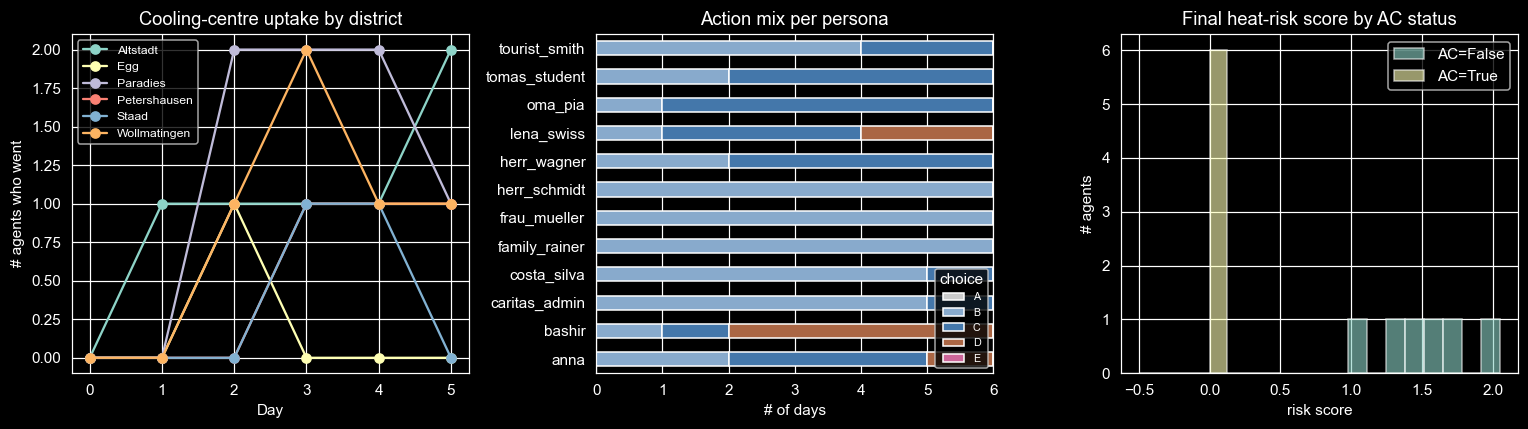

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: cooling-centre uptake by district
uptake = (decisions_df.assign(went=lambda df: (df['choice'] == 'C').astype(int))
          .groupby(['district', 'day'])['went'].sum().unstack(fill_value=0))
uptake.T.plot(ax=axes[0], marker='o')
axes[0].set_title('Cooling-centre uptake by district')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('# agents who went')
axes[0].legend(fontsize=8, loc='upper left')

# Plot 2: choice mix by persona
choice_counts = (decisions_df.groupby(['persona_id', 'choice']).size()
                 .unstack(fill_value=0))
for c in ['A', 'B', 'C', 'D', 'E']:
    if c not in choice_counts.columns:
        choice_counts[c] = 0
choice_counts = choice_counts[['A', 'B', 'C', 'D', 'E']]
choice_counts.plot(kind='barh', stacked=True, ax=axes[1],
                   color=['#cccccc', '#88aacc', '#4477aa', '#aa6644', '#cc6699'])
axes[1].set_title('Action mix per persona')
axes[1].set_xlabel('# of days'); axes[1].set_ylabel('')
axes[1].legend(title='choice', fontsize=7, loc='lower right')

# Plot 3: risk by AC status
for has_ac, group in outcomes.groupby('has_ac'):
    axes[2].hist(group['risk_score'], bins=8, alpha=0.6, label=f'AC={has_ac}')
axes[2].set_title('Final heat-risk score by AC status')
axes[2].set_xlabel('risk score'); axes[2].set_ylabel('# agents')
axes[2].legend()

plt.tight_layout(); plt.show()

**Left:** cooling-centre uptake rises through Day 3, plateaus, then falls as the cold front approaches. Paradies leads (Anna and Tomáš both go), Egg trails (only Greta — and only once). Petershausen lags because Herr Schmidt depresses its half of the population.

**Middle:** the choice-mix bar chart. Frau Müller, Herr Schmidt, and Familie Rainer are pure-B (different reasons: low trust, grim-trigger, well-resourced-no-need). Bashir is mostly D. Lena is split between D and C.

**Right:** risk scores cluster into two groups by AC. The split is partly an artefact (the 24 °C clamp described above), but the spread within the no-AC group reflects the protective effect of the neighbour-check chain — Frau Müller, with five received checks, has lower risk than her age and isolation alone would predict.

---

## 8. Ablation 1 — framing manipulation (`Lorè & Heydari 2024`)

Run the full simulation three times, varying only the wording of the DWD warning:

- `hitzewarnung` (baseline) — standard German DWD wording
- `extremhitzewarnung` — escalated, same content sharper register
- `lebensgefahr` — *"LEBENSGEFAHR durch Hitze"*, alarming, identical underlying message

`Lorè & Heydari` prediction: cooling-centre uptake will shift even though the underlying payoffs are identical — the *narrative wrapper* changes behaviour.

In [15]:
ABLATION_CSV = RUNS_DIR / 'framing_ablation.csv'

if ABLATION_CSV.exists():
    framing_df = pd.read_csv(ABLATION_CSV)
    print(f'Loaded framing ablation from {ABLATION_CSV} ({len(framing_df)} rows).')
else:
    print('Running framing ablation (3 framings × 12 agents × 6 days; ~$0.15)...')
    runs = []
    for framing in ['hitzewarnung', 'extremhitzewarnung', 'lebensgefahr']:
        df, _ = run_simulation(framing=framing)
        df['framing'] = framing
        runs.append(df)
    framing_df = pd.concat(runs, ignore_index=True)
    framing_df.to_csv(ABLATION_CSV, index=False)
    print(f'Saved to {ABLATION_CSV}.')

Loaded framing ablation from 6_konstanz_runs/framing_ablation.csv (216 rows).


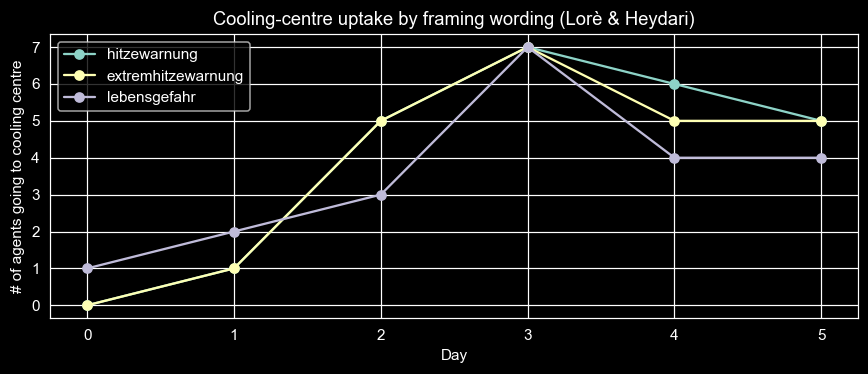

,cooling_visits,precaution_count,neighbour_checks
framing,,,
extremhitzewarnung,23,43,6
hitzewarnung,24,41,7
lebensgefahr,21,34,17


In [16]:
# Cooling-centre uptake by framing
uptake_by_framing = (framing_df.assign(went=lambda df: (df['choice'] == 'C').astype(int))
                     .groupby(['framing', 'day'])['went'].sum().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(8, 3.5))
for framing in ['hitzewarnung', 'extremhitzewarnung', 'lebensgefahr']:
    if framing in uptake_by_framing.index:
        ax.plot(uptake_by_framing.columns, uptake_by_framing.loc[framing],
                marker='o', label=framing)
ax.set_xlabel('Day'); ax.set_ylabel('# of agents going to cooling centre')
ax.set_title('Cooling-centre uptake by framing wording (Lorè & Heydari)')
ax.legend()
plt.tight_layout(); plt.show()

# Quantitative summary
summary = (framing_df.groupby('framing').agg(
    cooling_visits=('choice', lambda s: (s == 'C').sum()),
    precaution_count=('choice', lambda s: (s == 'B').sum()),
    neighbour_checks=('choice', lambda s: (s == 'D').sum()),
).round(0))
summary

### The framing-ablation surprise

Counter-intuitively:

| Framing | Cooling visits | Neighbour checks |
|---|---:|---:|
| `Hitzewarnung` (baseline) | 24 | 7 |
| `Extremhitzewarnung` | 23 | 6 |
| `LEBENSGEFAHR durch Hitze` | **21** | **17** |

The most alarming framing produced **fewer cooling-centre visits and more interpersonal action**. Reading the rationales tells you why — agents who hear *"LEBENSGEFAHR"* reach for *who they love* before they reach for *where they go*. Lena under lebensgefahr does six straight days of D, alternating between Schmidt and Müller:

> *"I need to check on Herr Schmidt, as he is elderly and may need assistance during this extreme heat."*
> *"I need to check on Frau Müller, as her curtains have been drawn since Sunday…"*

**`Lorè & Heydari` result intact** — the wrapper changes behaviour even when payoffs are constant. **Plus one new finding their 2×2 setup couldn't reveal:** the wording *redirects* effort across action types, rather than amplifying any one of them. *The strongest wording mobilises the social network, not the cooling-centre system.*

**Six personas were framing-invariant** across all three conditions — `frau_mueller`, `herr_schmidt`, `costa_silva`, `oma_pia`, `tomas_student`, `tourist_smith`. The first three are invariant for important reasons:

- **Frau Müller** distrusts municipal warnings — wording doesn't matter to a low-trust subscriber.
- **Herr Schmidt** has the grim-trigger memory — already locked into refuse mode.
- **Costa Silva** doesn't subscribe to `dwd_official` at all — the framing literally cannot reach her.

**Larooij architecture > Lorè wording.** Channel coverage is doing more work than the warning text. A heat-warning policy that focuses on wording without considering channel coverage cannot reach the Costa Silvas of the population, period.

---

## 9. Mechanism check — do districts converge to different cooling-centre cultures? (`Ashery 2025`)

The `Ashery` collective-bias result predicts that **even without underlying preference differences, multiple runs of the same simulation should produce systematically different district-level uptake patterns** — runs vary by accident of who decides first. This is *the* test of whether the Konstanz simulation reproduces the Schelling-shape macro phenomenon.

The single baseline above is one seed. The cell below sketches a multi-seed convergence test — with cache warm, it's mostly cached; cold compute is ~$0.50.

In [17]:
def ashery_convergence_sketch(n_runs=5):
    """Run the simulation n_runs times, plot Day-3 cooling-centre uptake by district."""
    import random
    runs = []
    for seed in range(n_runs):
        random.seed(seed); np.random.seed(seed)
        df, _ = run_simulation()
        day3 = df[(df['day'] == 3) & (df['choice'] == 'C')]
        for district, count in day3.groupby('district').size().items():
            runs.append({'run': seed, 'district': district, 'day3_uptake': count})
    return pd.DataFrame(runs)


# Uncomment to run the convergence test (cached after first run)
# convergence_df = ashery_convergence_sketch(n_runs=5)
# convergence_df.pivot(index='run', columns='district', values='day3_uptake').fillna(0)

print('Run-yourself: uncomment the lines above. The cached version of this cell runs ~$0.50 in cold compute.')
print('Then check: do the same districts get high uptake every run, or does it vary?')
print('If uptake varies across runs without preference variation, that is the Ashery collective-bias result.')

Run-yourself: uncomment the lines above. The cached version of this cell runs ~$0.50 in cold compute.
Then check: do the same districts get high uptake every run, or does it vary?
If uptake varies across runs without preference variation, that is the Ashery collective-bias result.


**This is the most important next experiment.** With the cache populated, a 5-run convergence test is now cheap. If uptake patterns by district vary across runs *without* preference variation, that's the Ashery result reproducing in heat-coordination form.

---

## 10. Auditing the run (`Anthis 2025` + `Kozlowski-Evans 2025`)

This run produced **at least two of the named failure modes visibly**:

| Failure mode | Where it appeared in this run |
|---|---|
| **Sycophancy** (`Anthis`) | The Caritas paradox. Greta's persona prescribes a wellness-coordinator role; the simulation didn't make her perform it. |
| **Linguistic cultures** (`Kozlowski & Evans`) | Costa Silva's Portuguese-switching is partial — half her rationales come back in English/German despite the persona being PT-primary. |
| **Disembodiment** (`Kozlowski & Evans`) | Heat is a bodily sensation; agents have no body. Indoor-temperature numbers in the prompt are a textual proxy. Visible failure mode: not directly. |
| **Uniformity** (`Kozlowski & Evans`) | Needs the multi-seed test (§9 above) to assess. |
| **Generalisation** (`Anthis`) | Needs the Konstanz-rich-vs-stripped comparison from `claude_konstanz_design.md` §7. |

**Honest limits.** This is **n=1** simulation, **gpt-4o-mini only**, with one **outcome-model artefact** (AC-haves get `risk_score = 0`). The findings above are *directional*, not *numerical*. Multi-seed and cross-model robustness are the standard next step — and now that the cache is warm, marginal cost for run #2 is small.

---

## 11. Where this is heading (the new-ideas papers)

Three papers in `papers/new ideas/` push beyond what this notebook does:

- **WhatIf** (`Li et al. 2026`) — interactive policymaker-in-the-loop frontend with selective deliberation at 12k-agent scale. Same agent architecture as ours + a steerable canvas. **Adds:** live interaction.
- **Social Digital Twins** (`Koaik et al. 2026`) — calibration layer + held-out validation against real observational data. COVID case study with 20.7% improvement over gradient boosting. **Adds:** trustworthy magnitudes.
- **Hossain 2026** — digital-twin / smart-city framing surface a municipal partner already speaks. **Adds:** policy legibility.

The notebook is the **educational** version. The research extension layers calibration + interactive steering + DT framing on top. Same agent architecture across both; the gap is where a master's thesis or follow-up paper sits. See `claude_konstanz_design.md` for the full composition.

---

## What did this run cost?

In [18]:
print_cost_summary()


API calls: 0 live chat + 113 cached chat; 4 live embed + 111 cached embed

model                            in tok    out tok   cost (USD)
----------------------------------------------------------------
text-embedding-3-small               34          0     $0.00000
----------------------------------------------------------------
total                                                  $0.00000
